# Moneylytics Baseline Experiment

## Goal
Build and evaluate a first baseline for expense category prediction based on transaction descriptions.

## Task
Multiclass classification.

## Target
`category`

## Input features
- `description`
- `amount` (not used in the first rule-based baseline)

## 1. Load Data

In this section, I load transaction data from the local SQLite database used in the Moneylytics bot.

In [36]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("moneylytics_bot.db")

df = pd.read_sql_query("""
SELECT user_id, amount, category, description, created_at
FROM expenses
""", conn)

conn.close()

df

,user_id,amount,category,description,created_at
0,543173591,50.00,Food,pizza,2026-03-04 15:49:02.492561
1,543173591,8.50,Transport,uber home,2026-04-27 11:11:31
2,543173591,14.20,Transport,bolt airport,2026-04-27 11:11:31
3,543173591,20.00,Transport,metro card,2026-04-27 11:11:31
4,543173591,2.10,Transport,bus ticket,2026-04-27 11:11:31
5,543173591,6.50,Transport,train lisbon,2026-04-27 11:11:31
6,543173591,12.00,Food,mcdonalds lunch,2026-04-27 11:11:31
7,543173591,4.80,Food,starbucks coffee,2026-04-27 11:11:31
8,543173591,23.40,Food,grocery lidl,2026-04-27 11:11:31
9,543173591,11.50,Food,pizza takeaway,2026-04-27 11:11:31


## 2. Data Cleaning

Before building a baseline, I normalize:
- category labels
- transaction descriptions

This helps avoid mismatches caused by capitalization or extra spaces.

In [37]:
df.category = df.category.str.strip().str.lower() # Normalize category names
unique_categories = df['category'].unique() # Get unique categories
count_unique_categories = df['category'].nunique() # Count unique categories

df.head()
df["category"].value_counts()
print(df.category[df.category.duplicated(keep=False)])


0              food
1         transport
2         transport
3         transport
4         transport
5         transport
6              food
7              food
8              food
9              food
10             food
11          housing
12          housing
13          housing
14          housing
15          housing
16    entertainment
17    entertainment
18    entertainment
19    entertainment
20    entertainment
21            other
22            other
23            other
24            other
25            other
Name: category, dtype: str


In [38]:
df.description = df.description.str.strip().str.lower() # Normalize description text
df.description = df.description.replace('', np.nan) #

print(df.description)

0                    pizza
1                uber home
2             bolt airport
3               metro card
4               bus ticket
5             train lisbon
6          mcdonalds lunch
7         starbucks coffee
8             grocery lidl
9           pizza takeaway
10             sushi lunch
11              rent april
12        electricity bill
13              water bill
14           internet home
15              ikea shelf
16    netflix subscription
17         spotify premium
18          cinema tickets
19              steam game
20           bowling night
21          pharmacy order
22            amazon order
23                 haircut
24                bank fee
25              phone case
Name: description, dtype: str


## 3. Rule-Based Baseline

I define a simple keyword-based baseline.

Idea:
- if a transaction description contains certain keywords,
- assign the corresponding category,
- otherwise return `other`.

In [39]:
dict_category_description = {'transport': {'uber', 'bolt', 'metro', 'bus', 'train', 'taxi'},
                            'food': {'mcdonalds', 'starbucks', 'grocery', 'pizza', 'restaurant', 'sushi', 'groceries', 'supermarket', 'food delivery', 'fast food', 'coffee shop', 'coffee'},
                            'entertainment': {'netflix', 'spotify', 'cinema', 'steam', 'xbox', 'playstation', 'gaming', 'concert', 'theater', 'movie', 'bowling'},
                            'housing': {'rent', 'electricity', 'water', 'internet', 'ikea'}
                             }



### Baseline Function

The function takes one transaction description and returns a predicted category based on keyword matching.

In [40]:
def assign_category(description):
    desc = description
    if pd.isna(desc) or not desc:
        return 'other'
    for category, keywords in dict_category_description.items():
        for keyword in keywords:
            if keyword in desc:
                return category
    return 'other'

## 4. Generate Predictions

Now I apply the rule-based function to all transaction descriptions and create the baseline predictions.

In [41]:
df['rule_pred'] = df['description'].apply(assign_category)
print(df[['description', 'category', 'rule_pred']])

             description       category      rule_pred
0                  pizza           food           food
1              uber home      transport      transport
2           bolt airport      transport      transport
3             metro card      transport      transport
4             bus ticket      transport      transport
5           train lisbon      transport      transport
6        mcdonalds lunch           food           food
7       starbucks coffee           food           food
8           grocery lidl           food           food
9         pizza takeaway           food           food
10           sushi lunch           food           food
11            rent april        housing        housing
12      electricity bill        housing        housing
13            water bill        housing        housing
14         internet home        housing        housing
15            ikea shelf        housing        housing
16  netflix subscription  entertainment  entertainment
17       s

## 5. Evaluate the Baseline

To evaluate the baseline, I compare:
- actual labels (`y_actual`)
- predicted labels (`y_pred`)

Metrics used:
- accuracy
- confusion matrix
- classification report

In [42]:
y_actual = df['category']
y_pred = df['rule_pred']
labels = ['entertainment', 'food', 'housing', 'other', 'transport']

### Accuracy

In [43]:
# 1. Calculate Accuracy
accuracy = accuracy_score(y_actual, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


### Confusion Matrix

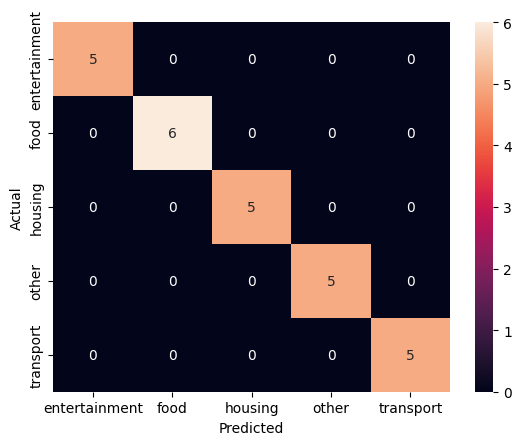

In [44]:
# 2. Confusion Matrix
conf_matrix = confusion_matrix(y_actual, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Classification Report

In [45]:
# 3. Classification Report
print(classification_report(y_actual, y_pred))

               precision    recall  f1-score   support

entertainment       1.00      1.00      1.00         5
         food       1.00      1.00      1.00         6
      housing       1.00      1.00      1.00         5
        other       1.00      1.00      1.00         5
    transport       1.00      1.00      1.00         5

     accuracy                           1.00        26
    macro avg       1.00      1.00      1.00        26
 weighted avg       1.00      1.00      1.00        26



## 6. Conclusion

The rule-based baseline shows perfect results on the toy dataset.

However, this result is optimistic because:
- the dataset is very small,
- the examples were manually constructed,
- the keyword rules are strongly aligned with the data.

This baseline was evaluated on the full toy dataset, so the result should not be treated as a realistic estimate of generalization.

## Next Step
Compare this rule-based baseline with a simple ML model such as:
- TF-IDF
- Logistic Regression

## 7. TF-IDF + Logistic Regression

Now I move from manual keyword rules to a simple ML pipeline.

This experiment will show whether a basic text model can perform competitively and serve as a stronger baseline for future improvements.